100%|██████████| 9.91M/9.91M [00:01<00:00, 6.05MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 159kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.59MB/s]


Epoch 1, Loss: 1.5317
Epoch 2, Loss: 1.4947
Epoch 3, Loss: 1.4818
Epoch 4, Loss: 1.4839
Epoch 5, Loss: 1.5032


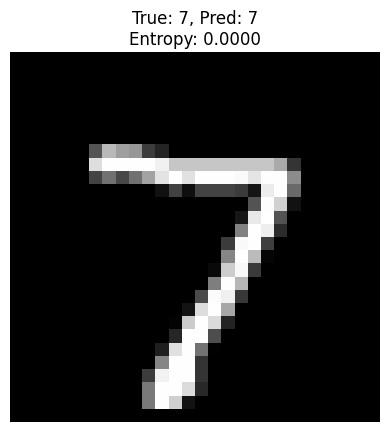

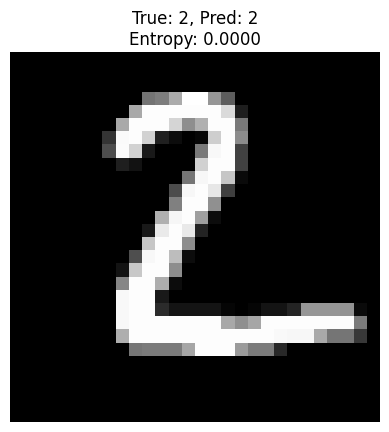

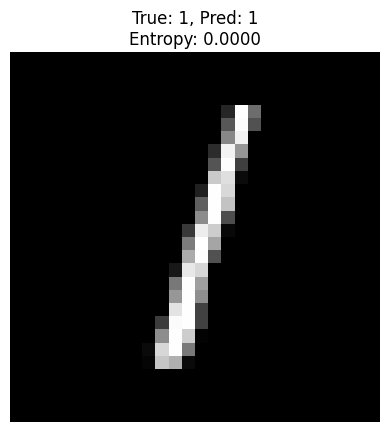

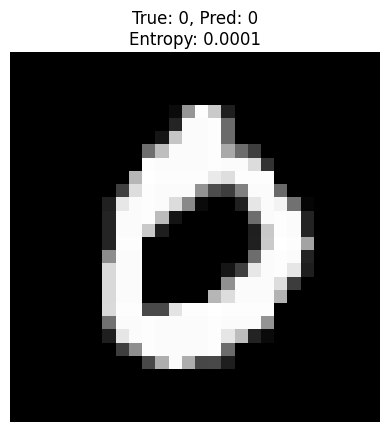

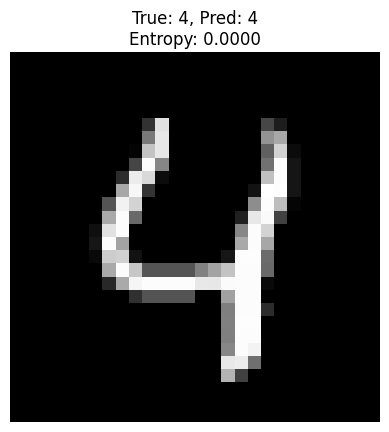

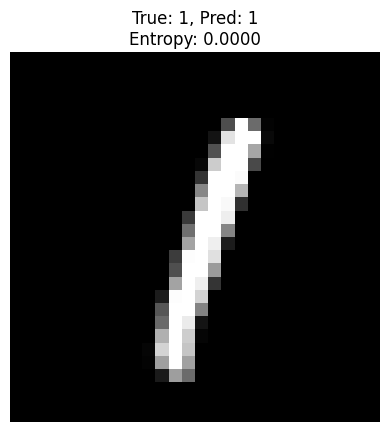

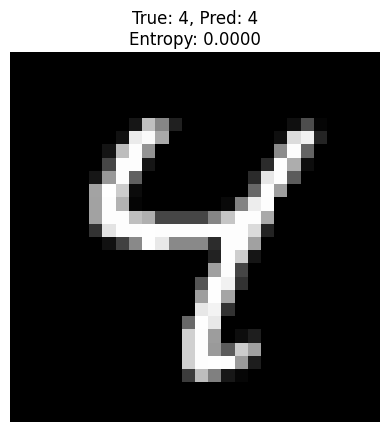

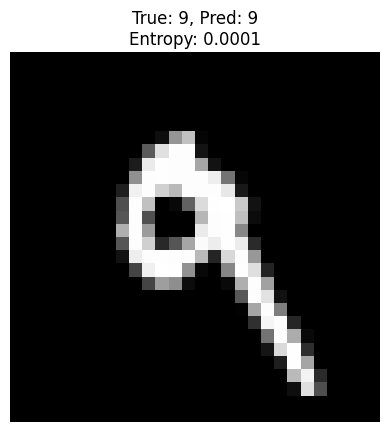

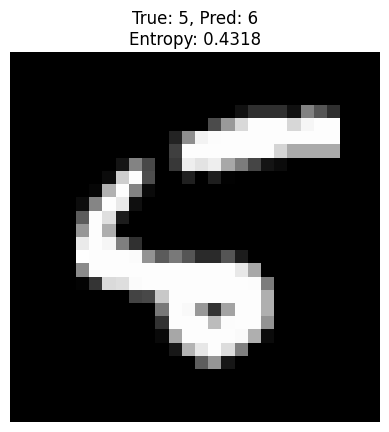

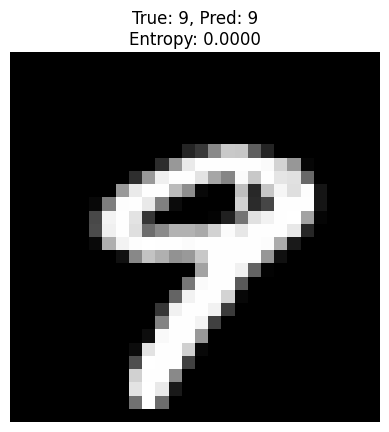

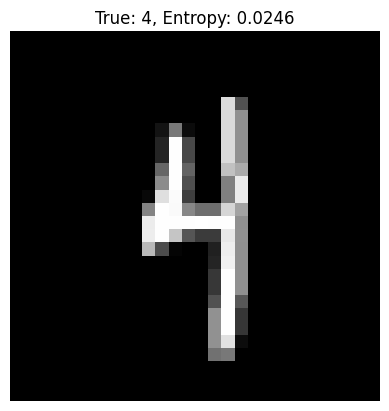

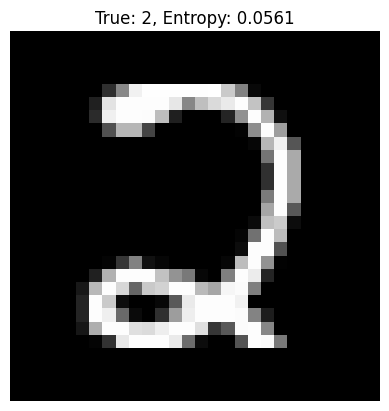

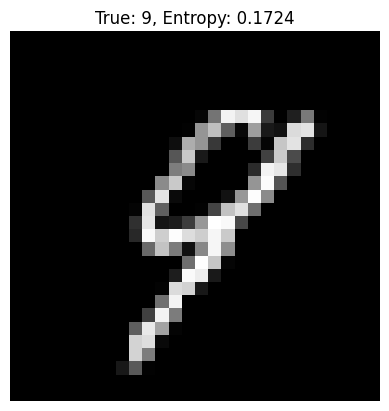

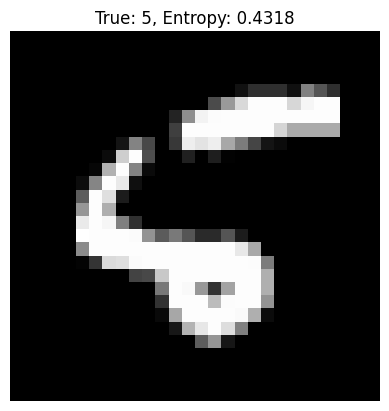

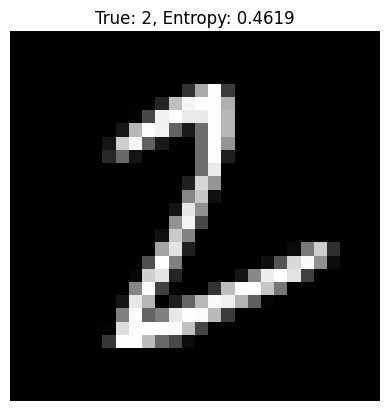

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()

mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)
test_loader = DataLoader(mnist_test, batch_size=1, shuffle=False)

class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return F.softmax(self.fc3(x), dim=1)

model = SimpleNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

model.train()
for epoch in range(5):
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

def entropy(p):
    return -torch.sum(p * torch.log(p + 1e-8), dim=1)

model.eval()
samples = [mnist_test[i] for i in range(10)]

for i, (x, label) in enumerate(samples):
    x_input = x.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(x_input)
        ent = entropy(output).item()
        pred_label = torch.argmax(output, dim=1).item()

    plt.imshow(x.squeeze(), cmap='gray')
    plt.title(f"True: {label}, Pred: {pred_label}\nEntropy: {ent:.4f}")
    plt.axis('off')
    plt.show()

uncertainties = []
labels = []
images = []

for i in range(100):  # 앞에서 100개만 예시로 확인
    x, y = mnist_test[i]
    x_input = x.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(x_input)
        ent = entropy(output).item()
    uncertainties.append(ent)
    labels.append(y)
    images.append(x)

topk = np.argsort(uncertainties)[-5:]

for i in topk:
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"True: {labels[i]}, Entropy: {uncertainties[i]:.4f}")
    plt.axis('off')
    plt.show()
